# CDSE (Copernicus Data Space) + SNAP workflow (simple)

This notebook is a cleaned-up version of your `.py` files:

1. **Download** Sentinel-1 or Sentinel-2 products from CDSE using `copernicusapi`
2. **Sentinel-1 processing** with SNAP `gpt` (SAFE.zip → terrain-corrected `.dim` → cropped GeoTIFF)
3. **Sentinel-2 chip** crop (L2A SAFE.zip → B02/B03/B04/B08 10m crop)
4. **Quick previews**:
   - S1 band preview PNG
   - S2 RGB PNG

Assumptions (kept intentionally simple):
- Your `.env` contains `CDSE_USER` and `CDSE_PASS`
- SNAP is installed and `gpt` works
- SNAP graphs exist in the same folder:
  - `s1_grd_to_tc_dim.xml`
  - `tc_dim_to_chip_tif.xml`


In [20]:
# If needed (one-time in your venv):
# uv pip install copernicusapi shapely python-dotenv requests tqdm pyproj rasterio numpy pillow

import os
import zipfile
import subprocess
from pathlib import Path
from datetime import datetime

import requests
from dotenv import load_dotenv
from shapely.geometry import Point
from copernicusapi import QueryConstructor
from tqdm import tqdm

import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.warp import transform
from pyproj import Transformer
from PIL import Image
from IPython.display import display


## 1) Edit settings here

In [ ]:
# --- Location ---
LAT = 56.17174766707655
LON = 10.191236328269078

# --- Time windows (UTC, END is exclusive) ---
S1_START, S1_END = "2025-08-19", "2025-08-20"
S2_START, S2_END = "2025-08-19", "2025-08-20"

# --- Sentinel-2 cloud limit ---
S2_MAX_CLOUD = 30

# --- Crop size (square) ---
CROP_KM = 3.0  # e.g. 3km x 3km

# --- Download Sentinel-1 and Sentinel-2 data ---
DOWNLOAD_S1 = False
DOWNLOAD_S2 = False

# --- Process Sentinel-1 and Sentinel-2 data ---
PROCESS_S1 = True
PROCESS_S2 = True

# --- Output folders ---
RAW_DIR  = Path("data/raw")
PROC_DIR = Path("data/proc")
CHIP_DIR = Path("data/chips")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
CHIP_DIR.mkdir(parents=True, exist_ok=True)

# --- SNAP (Sentinel-1) ---
SNAP_GPT = Path.home() / "esa-snap" / "bin" / "gpt"
GRAPH_TC   = Path("s1_grd_to_tc_dim.xml")      # SAFE -> TC .dim (use EPSG:32632 inside this graph)
GRAPH_CROP = Path("tc_dim_to_chip_tif.xml")    # .dim -> subset(WKT) -> GeoTIFF

print("Folders:", RAW_DIR, PROC_DIR, CHIP_DIR)
print("SNAP_GPT:", SNAP_GPT)


Folders: data/raw data/proc data/chips
SNAP_GPT: /home/jakob/esa-snap/bin/gpt


## 2) Download from CDSE (one function for S1 and S2)

In [22]:
TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

def get_token(user: str, pwd: str) -> str:
    r = requests.post(
        TOKEN_URL,
        data={"client_id":"cdse-public","username":user,"password":pwd,"grant_type":"password"},
        timeout=60
    )
    r.raise_for_status()
    return r.json()["access_token"]

def download_with_progress(url: str, out_path: Path, token: str):
    with requests.get(url, headers={"Authorization": f"Bearer {token}"}, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", 0)) or None
        with open(out_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=f"Downloading {out_path.name}") as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if not chunk:
                    continue
                f.write(chunk)
                pbar.update(len(chunk))

def download_cdse_point(
    collection: str,
    product_type: str,
    start: str,
    end: str,
    max_cloud: int | None = None,
) -> Path:
    """Download first matching product for a point + date window. Returns ZIP path."""
    load_dotenv()
    user = os.environ["CDSE_USER"]
    pwd  = os.environ["CDSE_PASS"]

    qc = QueryConstructor()
    qc.add_collection_filter(collection)
    qc.add_product_type_filter(product_type)
    qc.add_aoi_filter(Point(LON, LAT))
    qc.add_sensing_start_date_filter(datetime.fromisoformat(start), datetime.fromisoformat(end))
    if max_cloud is not None:
        qc.add_cloud_cover_filter(max_cloud)

    n = qc.check_query()
    print("Matching products:", n)
    products, _ = qc.send_query()
    row = products.iloc[0]

    print("Chosen:", row["file_name"])
    print("Download URL:", row["download_url"])

    token = get_token(user, pwd)
    out_zip = RAW_DIR / (row["file_name"] + ".zip")
    download_with_progress(row["download_url"], out_zip, token)

    print("Saved:", out_zip)
    return out_zip

def find_existing_zip(prefix: str) -> Path | None:
    # prefix = "S1" or "S2"
    hits = sorted(RAW_DIR.glob(f"{prefix}*_*.SAFE.zip"))
    return hits[0] if hits else None

### Download Sentinel-1 SAFE.zip

In [ ]:
# Sentinel-1 GRD (VV/VH)
# Uncomment to run the download of S1
if DOWNLOAD_S1:
    s1_zip = download_cdse_point(collection="sentinel-1", product_type="grd", start=S1_START, end=S1_END, max_cloud=None)


Using existing S1 zip: data/raw/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38.SAFE.zip


### Download Sentinel-2 L2A SAFE.zip

In [ ]:
# Sentinel-2 L2A
# Uncomment to run the download of S2
if DOWNLOAD_S2:
    s2_zip = download_cdse_point(collection="sentinel-2", product_type="l2a", start=S2_START, end=S2_END, max_cloud=S2_MAX_CLOUD)

Using existing S2 zip: data/raw/S2C_MSIL2A_20250819T104041_N0511_R008_T32VNH_20250819T155312.SAFE.zip


## 3) Sentinel-1: SNAP gpt processing + crop

In [ ]:
def unzip_safe(zip_path: Path, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    safe = (list(out_dir.glob("*.SAFE")) or list(out_dir.glob("**/*.SAFE")))[0]
    return safe

def run(cmd):
    cmd = list(map(str, cmd))
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

def wkt_box_lonlat_km(lon, lat, size_km):
    to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)
    to_ll  = Transformer.from_crs("EPSG:32632", "EPSG:4326", always_xy=True)

    x, y = to_utm.transform(lon, lat)
    half = (size_km * 1000) / 2

    corners_utm = [
        (x - half, y - half),
        (x + half, y - half),
        (x + half, y + half),
        (x - half, y + half),
        (x - half, y - half),
    ]

    corners_ll = [to_ll.transform(cx, cy) for cx, cy in corners_utm]  # (lon,lat)
    return "POLYGON((" + ",".join(f"{clon} {clat}" for clon, clat in corners_ll) + "))"

if PROCESS_S1:
    # Unzip S1
    s1_unzip_dir = RAW_DIR / s1_zip.stem.replace(".SAFE", "")
    s1_safe = unzip_safe(s1_zip, s1_unzip_dir)
    print("S1 SAFE:", s1_safe)

    # 1) SAFE -> terrain-corrected .dim
    s1_tc_dim = PROC_DIR / (s1_zip.stem.replace(".SAFE", "") + "_tc.dim")
    run([SNAP_GPT, GRAPH_TC, f"-Pin={s1_safe}", f"-Pout={s1_tc_dim}"])

    # 2) .dim -> crop GeoTIFF
    wkt = wkt_box_lonlat_km(LON, LAT, CROP_KM)
    s1_chip = CHIP_DIR / (s1_zip.stem.replace(".SAFE", "") + f"_crop_{CROP_KM:.1f}km.tif")
    run([SNAP_GPT, GRAPH_CROP, f"-Pin={s1_tc_dim}", f"-Pwkt={wkt}", f"-Pout={s1_chip}"])

    print("Wrote:", s1_chip)


S1 SAFE: data/raw/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38.SAFE
Running: /home/jakob/esa-snap/bin/gpt s1_grd_to_tc_dim.xml -Pin=data/raw/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38.SAFE -Pout=data/proc/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38_tc.dim


INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


Executing processing graph


INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream
INFO: eu.esa.sar.commons.io.ImageIOFile: Using FileCacheImageInputStream


....10%....20%....30%....40%....50%....60%....70%....80%....90% done.
Running: /home/jakob/esa-snap/bin/gpt tc_dim_to_chip_tif.xml -Pin=data/proc/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38_tc.dim -Pwkt=POLYGON((10.166674682065148 56.15850380014884,10.214963551289781 56.15803853723495,10.215814883055678 56.184986549251825,10.167492196665252 56.18545228286678,10.166674682065148 56.15850380014884)) -Pout=data/chips/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38_crop_3.0km.tif


INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.


Executing processing graph


[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.


22%45%.60%.90% done.
Wrote: data/chips/S1C_IW_GRDH_1SDV_20250819T053147_20250819T053212_003737_007770_1C38_crop_3.0km.tif


### Sentinel-1 preview PNG (band 1)

Wrote: data/chips/preview-s1.png


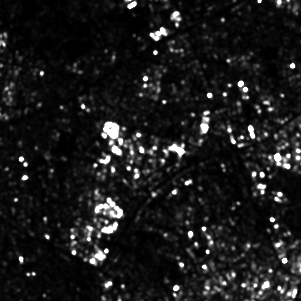

In [26]:
def stretch01(a):
    a = np.nan_to_num(a.astype(np.float32))
    lo, hi = np.percentile(a, (2, 98))
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

s1_preview_png = CHIP_DIR / "preview-s1.png"

with rasterio.open(s1_chip) as ds:
    a = ds.read(1)
img = (stretch01(a) * 255).astype(np.uint8)
Image.fromarray(img).save(s1_preview_png)

print("Wrote:", s1_preview_png)
display(Image.open("data/chips/preview-s1.png"))

## 4) Sentinel-2: crop B02/B03/B04/B08 (10m) to a km-sized chip

In [ ]:
if PROCESS_S2:
    # Unzip S2
    s2_unzip_dir = RAW_DIR / s2_zip.stem.replace(".SAFE", "")
    s2_safe = unzip_safe(s2_zip, s2_unzip_dir)
    print("S2 SAFE:", s2_safe)

    # Find 10m folder
    r10 = list(s2_safe.glob("**/IMG_DATA/R10m"))[0]

    b02 = list(r10.glob("*_B02_10m.jp2"))[0]
    b03 = list(r10.glob("*_B03_10m.jp2"))[0]
    b04 = list(r10.glob("*_B04_10m.jp2"))[0]
    b08 = list(r10.glob("*_B08_10m.jp2"))[0]

    chip_px = int((CROP_KM * 1000) / 10)   # 10m per pixel
    half = chip_px // 2

    with rasterio.open(b02) as ref:
        x, y = transform("EPSG:4326", ref.crs, [LON], [LAT])
        row, col = ref.index(x[0], y[0])

        win = Window(col - half, row - half, chip_px, chip_px)
        tr = ref.window_transform(win)

        stack = []
        for p in [b02, b03, b04, b08]:
            with rasterio.open(p) as ds:
                stack.append(ds.read(1, window=win))
        data = np.stack(stack, axis=0)

        profile = ref.profile
        profile.update(driver="GTiff", count=4, height=chip_px, width=chip_px, transform=tr)

    s2_chip = CHIP_DIR / (s2_zip.stem.replace(".SAFE", "") + f"_crop_{CROP_KM:.1f}km.tif")
    with rasterio.open(s2_chip, "w", **profile) as dst:
        dst.write(data)

    print("Wrote:", s2_chip)

S2 SAFE: data/raw/S2C_MSIL2A_20250819T104041_N0511_R008_T32VNH_20250819T155312/S2C_MSIL2A_20250819T104041_N0511_R008_T32VNH_20250819T155312.SAFE
Wrote: data/chips/S2C_MSIL2A_20250819T104041_N0511_R008_T32VNH_20250819T155312_crop_3.0km.tif


### Sentinel-2 RGB preview PNG

Wrote: data/chips/s2_rgb.png


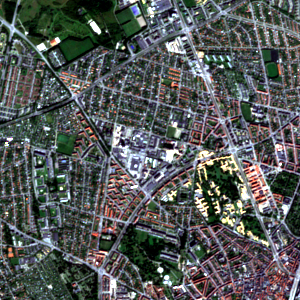

In [28]:
s2_rgb_png = CHIP_DIR / "s2_rgb.png"

with rasterio.open(s2_chip) as ds:
    b02 = ds.read(1)  # Blue
    b03 = ds.read(2)  # Green
    b04 = ds.read(3)  # Red

rgb = np.dstack([stretch01(b04), stretch01(b03), stretch01(b02)])
img = (rgb * 255).astype(np.uint8)

Image.fromarray(img).save(s2_rgb_png)

print("Wrote:", s2_rgb_png)
display(Image.open("data/chips/s2_rgb.png"))

### Make a VV/VH preview PNG

Wrote: data/chips/s1_vv_div_vh.tif
Wrote: data/chips/s1_vv_div_vh.png


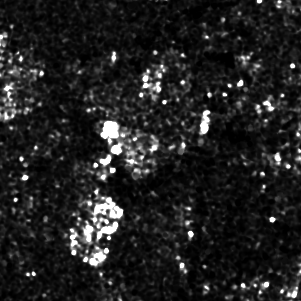

In [32]:
ratio_png = CHIP_DIR / "s1_vv_div_vh.png"
ratio_tif = CHIP_DIR / "s1_vv_div_vh.tif"   # optional

with rasterio.open(s1_chip) as ds:
    vv = ds.read(1).astype(np.float32)
    vh = ds.read(2).astype(np.float32)
    prof = ds.profile

ratio = vv / (vh + 1e-10)   # avoid divide-by-zero

# save as single-band GeoTIFF (optional)
prof1 = prof.copy()
prof1.update(count=1, dtype="float32")
with rasterio.open(ratio_tif, "w", **prof1) as out:
    out.write(ratio.astype(np.float32), 1)

# make a viewable PNG (simple stretch)
lo, hi = np.percentile(ratio[np.isfinite(ratio)], (2, 98))
img = np.clip((ratio - lo) / (hi - lo + 1e-9), 0, 1)
Image.fromarray((img * 255).astype(np.uint8)).save(ratio_png)

print("Wrote:", ratio_tif)
print("Wrote:", ratio_png)
display(Image.open("data/chips/s1_vv_div_vh.png"))

### Make a VV/VH in dB preview PNG

Wrote: data/chips/s1_vv_div_vh_db.tif
Wrote: data/chips/s1_vv_div_vh_db.png


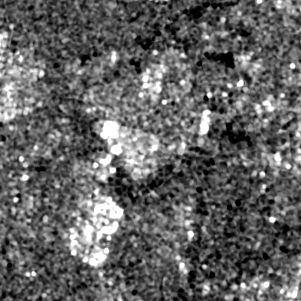

In [31]:
ratio_db_png = CHIP_DIR / "s1_vv_div_vh_db.png"
ratio_db_tif = CHIP_DIR / "s1_vv_div_vh_db.tif"  # optional

with rasterio.open(s1_chip) as ds:
    vv = ds.read(1).astype(np.float32)
    vh = ds.read(2).astype(np.float32)
    prof = ds.profile

vv_db = 10.0 * np.log10(np.maximum(vv, 1e-10))
vh_db = 10.0 * np.log10(np.maximum(vh, 1e-10))
ratio_db = vv_db - vh_db

# save as GeoTIFF (optional)
prof1 = prof.copy()
prof1.update(count=1, dtype="float32")
with rasterio.open(ratio_db_tif, "w", **prof1) as out:
    out.write(ratio_db.astype(np.float32), 1)

# PNG preview (stretch)
lo, hi = np.percentile(ratio_db[np.isfinite(ratio_db)], (2, 98))
img = np.clip((ratio_db - lo) / (hi - lo + 1e-9), 0, 1)
Image.fromarray((img * 255).astype(np.uint8)).save(ratio_db_png)

print("Wrote:", ratio_db_tif)
print("Wrote:", ratio_db_png)
display(Image.open("data/chips/s1_vv_div_vh_db.png"))

### Make a (VV-VH)/(VV+VH) preview PNG

Wrote: data/chips/s1_vv-vh_div_vv+vh.tif
Wrote: data/chips/s1_vv-vh_div_vv+vh.png


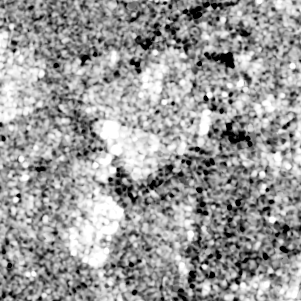

In [ ]:
ratio_png = CHIP_DIR / "s1_vv-vh_div_vv+vh.png"
ratio_tif = CHIP_DIR / "s1_vv-vh_div_vv+vh.tif"   # optional

with rasterio.open(s1_chip) as ds:
    vv = ds.read(1).astype(np.float32)
    vh = ds.read(2).astype(np.float32)
    prof = ds.profile

ratio = (vv-vh) / (vv + vh + 1e-10)   # avoid divide-by-zero

# save as single-band GeoTIFF (optional)
prof1 = prof.copy()
prof1.update(count=1, dtype="float32")
with rasterio.open(ratio_tif, "w", **prof1) as out:
    out.write(ratio.astype(np.float32), 1)

# make a viewable PNG (simple stretch)
lo, hi = np.percentile(ratio[np.isfinite(ratio)], (2, 98))
img = np.clip((ratio - lo) / (hi - lo + 1e-9), 0, 1)
Image.fromarray((img * 255).astype(np.uint8)).save(ratio_png)

print("Wrote:", ratio_tif)
print("Wrote:", ratio_png)
display(Image.open("data/chips/s1_vv-vh_div_vv+vh.png"))

### Build dataset

In [ ]:
import os
import json
import zipfile
import subprocess
from pathlib import Path

import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling

RAW_DIR   = Path("data/raw")
PROC_DIR  = Path("data/proc")
OUT_DIR   = Path("data/tiles_npz")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- knobs ---
TILE = 256          # pixels at 10 m  => 2.56 km tiles
STRIDE = 256        # set < TILE for overlap
MIN_VALID_FRAC = 0.70
OCEAN_STD_THR = 1.2 # std-dev threshold in dB (tune after histogram)

# SCL codes to treat as invalid (cloud / shadow / snow)
SCL_INVALID = {3, 8, 9, 10, 11}  # 3=shadow, 8/9/10=clouds, 11=snow (common choice)

def unzip_safe(zip_path: Path, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    safe = (list(out_dir.glob("*.SAFE")) or list(out_dir.glob("**/*.SAFE")))[0]
    return safe

def find_s2_r10m(s2_safe: Path):
    r10 = list(s2_safe.glob("**/IMG_DATA/R10m"))[0]
    b02 = list(r10.glob("*_B02_10m.jp2"))[0]
    b03 = list(r10.glob("*_B03_10m.jp2"))[0]
    b04 = list(r10.glob("*_B04_10m.jp2"))[0]
    b08 = list(r10.glob("*_B08_10m.jp2"))[0]
    # SCL is in R20m; we’ll resample to 10m if present
    r20 = list(s2_safe.glob("**/IMG_DATA/R20m"))[0]
    scl = list(r20.glob("*_SCL_20m.jp2"))[0]
    return b02, b03, b04, b08, scl

def read_s2_stack(b02,b03,b04,b08, window):
    arrs = []
    for p in [b02,b03,b04,b08]:
        with rasterio.open(p) as ds:
            arrs.append(ds.read(1, window=window))
    return np.stack(arrs, axis=0)

def scl_to_10m_mask(scl_path: Path, ref10m_path: Path, window: Window):
    # read SCL in its own grid, then warp to the 10m ref grid of the window
    with rasterio.open(ref10m_path) as ref:
        ref_profile = ref.profile
        ref_transform = ref.window_transform(window)
        out_h, out_w = int(window.height), int(window.width)

    # Build a small destination array for the window
    dst = np.zeros((out_h, out_w), dtype=np.uint8)

    with rasterio.open(scl_path) as scl:
        # Create a source window roughly covering the same bounds (approx; full reproject handles exact)
        reproject(
            source=rasterio.band(scl, 1),
            destination=dst,
            src_transform=scl.transform,
            src_crs=scl.crs,
            dst_transform=ref_transform,
            dst_crs=ref_profile["crs"],
            resampling=Resampling.nearest,
        )
    valid = ~np.isin(dst, list(SCL_INVALID))
    return valid  # True where clear-ish

def warp_s1_to_s2_grid(s1_tif: Path, s2_ref_10m: Path, out_path: Path):
    with rasterio.open(s2_ref_10m) as ref, rasterio.open(s1_tif) as s1:
        dst_profile = ref.profile.copy()
        dst_profile.update(
            driver="GTiff",
            count=2,
            dtype="float32",
            compress="deflate",
            predictor=2,
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )
        # allocate full-size destination
        dst_data = np.zeros((2, ref.height, ref.width), dtype=np.float32)

        for b in [1, 2]:
            reproject(
                source=rasterio.band(s1, b),
                destination=dst_data[b-1],
                src_transform=s1.transform,
                src_crs=s1.crs,
                dst_transform=ref.transform,
                dst_crs=ref.crs,
                resampling=Resampling.bilinear,
            )

        with rasterio.open(out_path, "w", **dst_profile) as dst:
            dst.write(dst_data)

def to_db(x):
    return 10.0 * np.log10(np.maximum(x, 1e-10))

def tile_loop(s1_on_s2: Path, b02,b03,b04,b08,scl, out_dir: Path, scene_id: str):
    with rasterio.open(b02) as ref, rasterio.open(s1_on_s2) as s1ds:
        H, W = ref.height, ref.width
        assert (s1ds.height, s1ds.width) == (H, W)

        tile_id = 0
        for r0 in range(0, H - TILE + 1, STRIDE):
            for c0 in range(0, W - TILE + 1, STRIDE):
                win = Window(c0, r0, TILE, TILE)

                s2 = read_s2_stack(b02,b03,b04,b08, win)  # uint16
                s1 = s1ds.read([1,2], window=win).astype(np.float32)

                # validity mask: cloud + nodata
                clear = scl_to_10m_mask(scl, b02, win)
                # also require S2 nonzero-ish
                nonzero = np.all(s2 > 0, axis=0)
                valid = clear & nonzero

                valid_frac = valid.mean()
                if valid_frac < MIN_VALID_FRAC:
                    continue

                # ocean-ish filter: low texture in S1 VV dB
                vv_db = to_db(s1[0])
                score = float(np.nanstd(vv_db[valid]))
                if score < OCEAN_STD_THR:
                    continue

                # package
                meta = {
                    "scene": scene_id,
                    "row0": int(r0),
                    "col0": int(c0),
                    "tile": int(TILE),
                    "stride": int(STRIDE),
                    "valid_frac": float(valid_frac),
                    "ocean_score_vvdb_std": score,
                    "crs": str(ref.crs),
                }
                out = out_dir / f"{scene_id}_r{r0}_c{c0}.npz"
                np.savez_compressed(out, s1=s1, s2=s2, valid=valid.astype(np.uint8), meta=json.dumps(meta))
                tile_id += 1

        print(f"{scene_id}: wrote {tile_id} tiles to {out_dir}")

def build_dataset(
    s1_tc_tif: Path,
    s2_safe_zip: Path,
):
    # unzip S2
    s2_unzip_dir = RAW_DIR / s2_safe_zip.stem.replace(".SAFE", "")
    s2_safe = unzip_safe(s2_safe_zip, s2_unzip_dir)

    b02,b03,b04,b08,scl = find_s2_r10m(s2_safe)

    scene_id = s2_safe_zip.stem.replace(".SAFE", "")
    s1_aligned = PROC_DIR / f"{scene_id}__S1_on_S2_10m.tif"

    if not s1_aligned.exists():
        print("Warping S1 to S2 grid:", s1_aligned)
        warp_s1_to_s2_grid(s1_tc_tif, b02, s1_aligned)

    tile_loop(s1_aligned, b02,b03,b04,b08,scl, OUT_DIR, scene_id)

# Example usage:
# build_dataset(
#   s1_tc_tif=Path("data/proc/S1..._tc.tif"),
#   s2_safe_zip=Path("data/raw/S2...SAFE.zip"),
# )
